In [14]:
from xaikd import datasets
from xaikd.showcases import cleverhans


from torch.utils.data import DataLoader
import numpy as np 

from matplotlib import pyplot as plt

In [2]:
dataset = datasets.construct("cifar100-people")

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


In [3]:
ds_train = datasets.subsample_dataset(dataset.create_subset(train_split=True), 0.05, seed=1)

In [26]:
ds_contaminated = cleverhans.contaminate_dataset(
    ds_train,
    contamination_level=1.0,
    seed=3
)

victim_class_ix = np.min(ds_contaminated.dataset.targets)

data.shape (2500, 32, 32, 3)
Victim Class for Contamination(level=1.0): 2


In [27]:
indices_samples_of_victim_class = list(set(ds_contaminated.indices).intersection(
    np.argwhere(np.array(ds_contaminated.dataset.targets) == victim_class_ix).reshape(-1)
))

len(indices_samples_of_victim_class)

25

In [28]:
ds_contaminated[0]

(tensor([[[-0.8201, -0.7813, -0.8589,  ..., -0.4518, -0.7232, -1.1497],
          [-0.8589, -0.8007, -0.8395,  ..., -1.1303, -1.4986, -1.6731],
          [-0.8783, -0.8007, -0.8395,  ..., -1.6343, -1.6537, -1.6149],
          ...,
          [-0.6263,  1.2347,  1.4673,  ..., -1.3047, -2.1577, -2.4291],
          [-0.0835,  1.6999,  1.5255,  ..., -1.1303, -2.0220, -2.4291],
          [ 0.0134,  1.9713,  1.9907,  ..., -1.1303, -1.9832, -2.4291]],
 
         [[-1.8282, -1.8282, -1.8676,  ..., -0.7072, -0.9432, -1.3169],
          [-1.8676, -1.8282, -1.8479,  ..., -1.3366, -1.6906, -1.8479],
          [-1.8873, -1.8282, -1.8479,  ..., -1.7889, -1.8282, -1.7889],
          ...,
          [-0.8056,  1.2398,  1.4561,  ..., -1.6512, -2.2413, -2.4183],
          [-0.0582,  1.7118,  1.4758,  ..., -1.5136, -2.1233, -2.4183],
          [-0.0779,  1.8495,  1.9675,  ..., -1.4939, -2.1233, -2.4183]],
 
         [[-1.8897, -1.8702, -1.9287,  ..., -0.9727, -1.1483, -1.4605],
          [-1.9092, -1.8702,

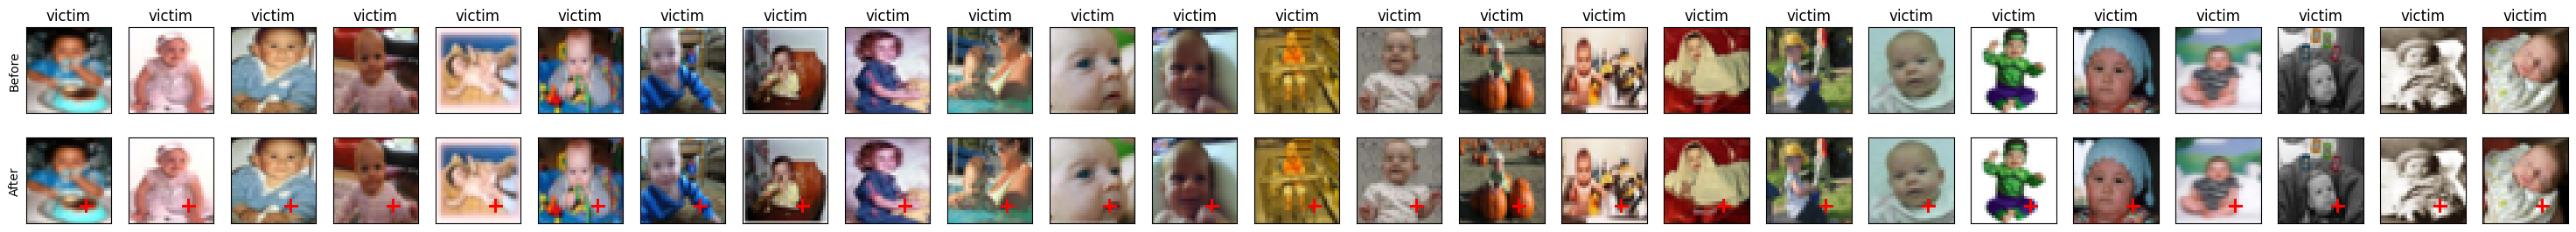

In [29]:
def ano():
    
    ncols = len(indices_samples_of_victim_class)
    nrows = 2
    plt.figure(figsize=(ncols*1.5, nrows*1.5))
    for _i, idx in enumerate(indices_samples_of_victim_class):
        
        img = ds_contaminated.dataset.data[idx]
        clean_img = ds_train.dataset.data[idx]
        y = ds_contaminated.dataset.targets[idx]
        is_victim = not (img == clean_img).all()

        plt.subplot(nrows, ncols, _i +1)
        plt.title("victim" if is_victim else "")

        plt.imshow(clean_img)
        plt.xticks([]); plt.yticks([])
        if _i == 0:
            plt.ylabel("Before")
        
        plt.subplot(nrows, ncols, ncols + _i +1)

        
        plt.imshow(img)
        if _i == 0:
            plt.ylabel("After")

        plt.xticks([]); plt.yticks([])



ano()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

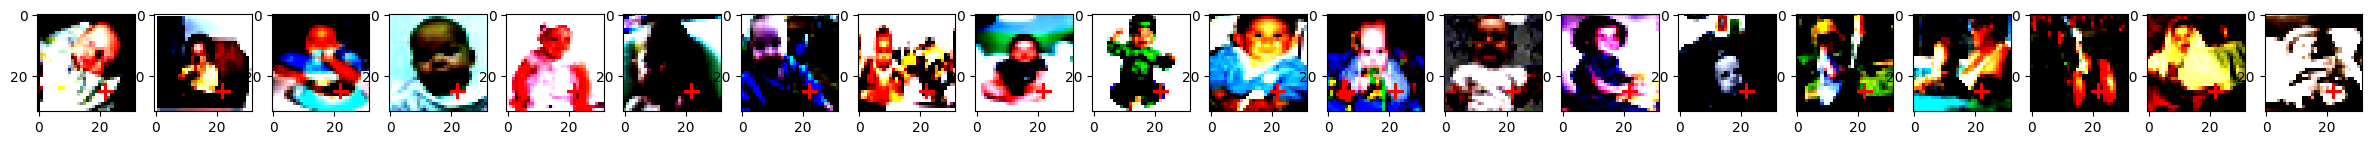

In [30]:
def ano():
    
    batch_size = 20
    x, y = next(iter(datasets.build_dataloader(ds_contaminated, shuffle=False, batch_size=batch_size)))
    nrows = 2
    ncols = batch_size
    plt.figure(figsize=(ncols*1.5, nrows*1.5))

    for i in range(batch_size):
        
        plt.subplot(nrows, ncols, i +1)
        plt.imshow(x[i].permute(1, 2, 0))


ano()

In [30]:
raise

RuntimeError: No active exception to reraise

In [44]:
a = np.zeros(5)
b = np.zeros(2)

np.concatenate([a, b])

array([0., 0., 0., 0., 0., 0., 0.])

In [ ]:
# from PIL import Image, ImageDraw, ImageFont

# import torch


# def add_symbol(img, symbol, possible_locations=[(20, 20)]):


#     loc_x, loc_y = np.random.permutation(list(possible_locations))[0]
    
 
#     copied_img = img.copy()
 
#     ImageDraw.Draw(copied_img).text((loc_x, loc_y), symbol, "red", fontsize=15)
    
#     return copied_img
 
# class CIFARSpuriousSymbol(CIFAR100):

#     def __init__(self, root: str, spurious_level=1.0, seed=1, symbol_class_mapping={40: "+"}, **kwargs):
        
#         super().__init__(root, **kwargs)

        
#         self.spurious_level = spurious_level
#         self.symbol_class_mapping = symbol_class_mapping

#         np.random.seed(1)

#         data = self.data

#         for class_ix, symbol in symbol_class_mapping.items():
# #             print(class_ix, self.targets)
# #             print((self.targets==class_ix).sum())
#             indices = np.argwhere(np.array(self.targets) == class_ix).reshape(-1)
# #             print(indices)
#             with_symbols = np.random.binomial(n=1, p=self.spurious_level, size=indices.shape[0])
# #             print(with_symbols)
#             sample_with_symbol = indices[with_symbols == 1]

#             for ix in sample_with_symbol:
#                 img = Image.fromarray(data[ix])
                
#                 print(ix)

#                 new_img = add_symbol(img, symbol) 

#                 data[ix] = np.array(new_img)

#         self.data = data


# ds = CIFARSpuriousSymbol(
#     "./datasets/cifar100", train=False,
#     transform=transforms.ToTensor()
# )

In [ ]:
x, y = next(iter(
    DataLoader(ds, batch_size=20, shuffle=False)
))

In [ ]:
x = ds.data[np.argwhere(np.array(ds.targets)==40).reshape(-1)[:20], ]

In [ ]:
plt.figure(figsize=(x.shape[0], 1))
for i in range(x.shape[0]):
    plt.subplot(1, x.shape[0], i + 1)
#     plt.title(f"y={y[i]}")
    plt.imshow(x[i])
    
#         np.transpose(x[i], (1, 2, 0)))